In [4]:
!git clone https://github.com/Hamzaabba2005/Dissertation.git

fatal: destination path 'Dissertation' already exists and is not an empty directory.


In [5]:
import sys
sys.path.append("/kaggle/working/Dissertation/src")

In [6]:
# configuration
from config import *

# reproducibility
from reproducibility import seed_everything

# dataset utilities
from auto_detect import pick_images_dir
from build_samples import build_samples_existing
from patient_level_split import patient_level_split

# transforms
from transforms_config import get_transforms

# dataloaders
from dataset import create_dataloaders

# class imbalance handling
from class_weights import compute_pos_weight

# models
from model import build_model

In [7]:
import os
import random
import copy
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score

In [8]:
from config import *

BASE_PATH = os.getenv("DATASET_PATH", "/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k")
CSV_PATH = os.path.join(BASE_PATH, "full_df.csv")
IMAGES_DIR = os.path.join(BASE_PATH, "preprocessed_images")

print("CSV exists:", os.path.exists(CSV_PATH))
print("Images dir exists:", os.path.exists(IMAGES_DIR))
print("Device:", DEVICE)

CSV exists: True
Images dir exists: True
Device: cuda


In [9]:
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
print("Current device:", torch.cuda.current_device() if torch.cuda.is_available() else "CPU")
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
Device count: 1
Current device: 0
GPU name: Tesla P100-PCIE-16GB


In [10]:
from reproducibility import seed_everything

SEED = 42
seed_everything(SEED)

In [11]:
df = pd.read_csv(CSV_PATH)
print("CSV shape:", df.shape)
print(df.head())

CSV shape: (6392, 19)
   ID  Patient Age Patient Sex Left-Fundus Right-Fundus  \
0   0           69      Female  0_left.jpg  0_right.jpg   
1   1           57        Male  1_left.jpg  1_right.jpg   
2   2           42        Male  2_left.jpg  2_right.jpg   
3   4           53        Male  4_left.jpg  4_right.jpg   
4   5           50      Female  5_left.jpg  5_right.jpg   

                            Left-Diagnostic Keywords  \
0                                           cataract   
1                                      normal fundus   
2  laser spot，moderate non proliferative retinopathy   
3                        macular epiretinal membrane   
4             moderate non proliferative retinopathy   

                Right-Diagnostic Keywords  N  D  G  C  A  H  M  O  \
0                           normal fundus  0  0  0  1  0  0  0  0   
1                           normal fundus  1  0  0  0  0  0  0  0   
2  moderate non proliferative retinopathy  0  1  0  0  0  0  0  1   
3       mi

In [12]:
from auto_detect import pick_images_dir

auto_dir, hits = pick_images_dir(BASE_PATH, df)

if auto_dir is not None and hits > 0:
    IMAGES_DIR = auto_dir

print("Selected IMAGES_DIR:", IMAGES_DIR)
print("Hits:", hits)

Selected IMAGES_DIR: /kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k/preprocessed_images
Hits: 39


In [13]:
from build_samples import build_samples_existing

samples, missing, bad_labels = build_samples_existing(
    df,
    IMAGES_DIR,
    LABEL_COLS
)

print("Total usable samples:", len(samples))
print("Missing images:", missing)
print("Bad label rows:", bad_labels)

Total usable samples: 12460
Missing images: 324
Bad label rows: 0


In [14]:
from patient_level_split import patient_level_split

train_samples, val_samples = patient_level_split(
    samples,
    VAL_SIZE,
    SEED
)

train_patients = set(s["patient_id"] for s in train_samples)
val_patients = set(s["patient_id"] for s in val_samples)

print("Train samples:", len(train_samples))
print("Val samples:", len(val_samples))
print("Unique train patients:", len(train_patients))
print("Unique val patients:", len(val_patients))
print("Patient overlap:", len(train_patients & val_patients))


Train samples: 10609
Val samples: 1851
Unique train patients: 2854
Unique val patients: 504
Patient overlap: 0


In [15]:
from transforms_config import get_transforms

train_tfm, val_tfm = get_transforms(IMG_SIZE)

In [16]:
from dataset import create_dataloaders

train_ds, val_ds, train_loader, val_loader = create_dataloaders(
    train_samples,
    val_samples,
    train_tfm,
    val_tfm
)
print("Dataset sizes:", len(train_ds), len(val_ds))

Dataset sizes: 10609 1851


In [17]:
from class_weights import compute_pos_weight

pos_weight = compute_pos_weight(train_samples).to(DEVICE)
print("pos_weight:", pos_weight)

pos_weight: tensor([ 2.0054,  1.9486, 15.4481, 14.5102, 19.0170, 30.9548, 20.0496,  3.3640],
       device='cuda:0')


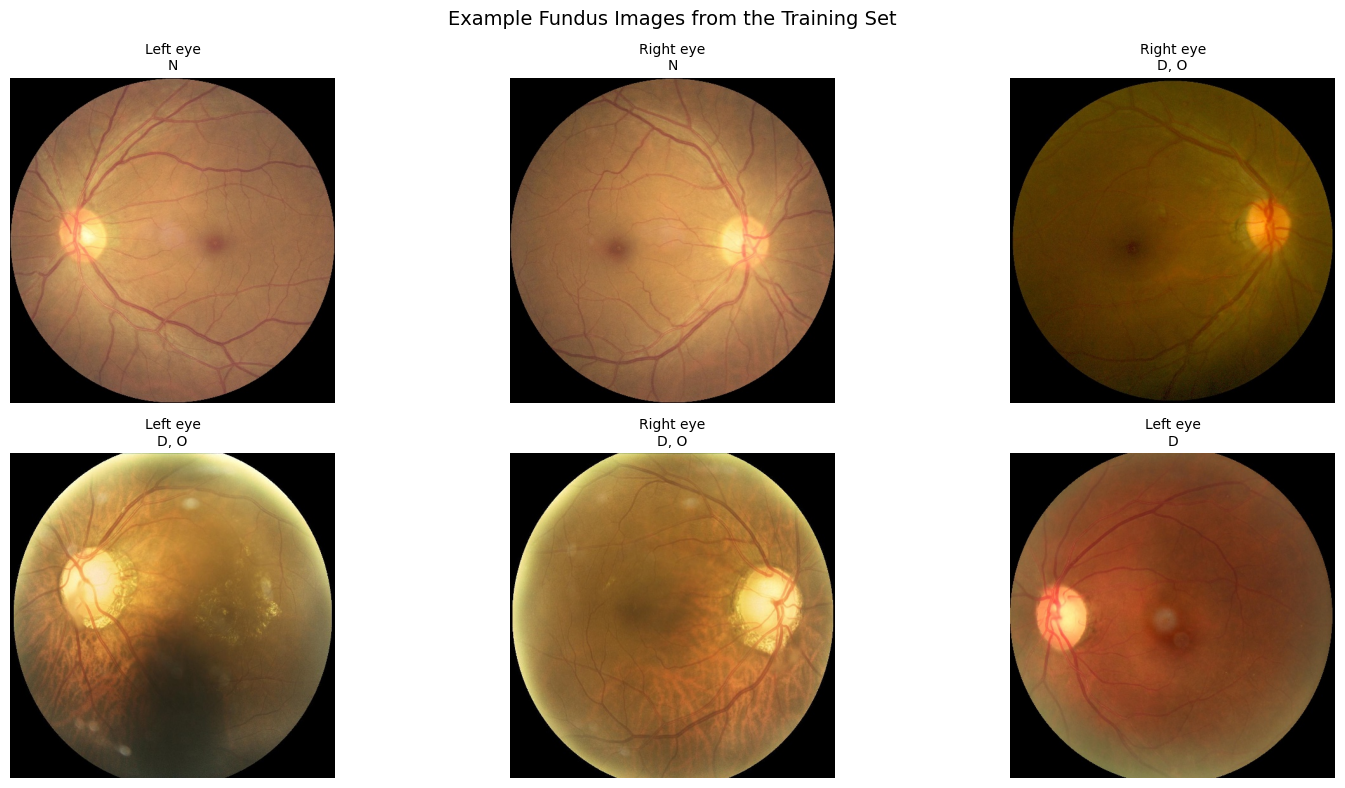

In [18]:
import matplotlib.pyplot as plt
from PIL import Image

def show_sample_images(samples, n=6):
    n = min(n, len(samples))
    fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(16, 8))
    axes = np.array(axes).reshape(-1)

    for ax, sample in zip(axes, samples[:n]):
        img = Image.open(sample["path"]).convert("RGB")
        ax.imshow(img)
        positive_labels = [LABEL_COLS[i] for i, v in enumerate(sample["label"]) if v > 0]
        ax.set_title(f"{sample['side']} eye\n" + ", ".join(positive_labels), fontsize=10)
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.suptitle("Example Fundus Images from the Training Set", fontsize=14)
    plt.tight_layout()
    plt.show()

show_sample_images(train_samples, n=6)

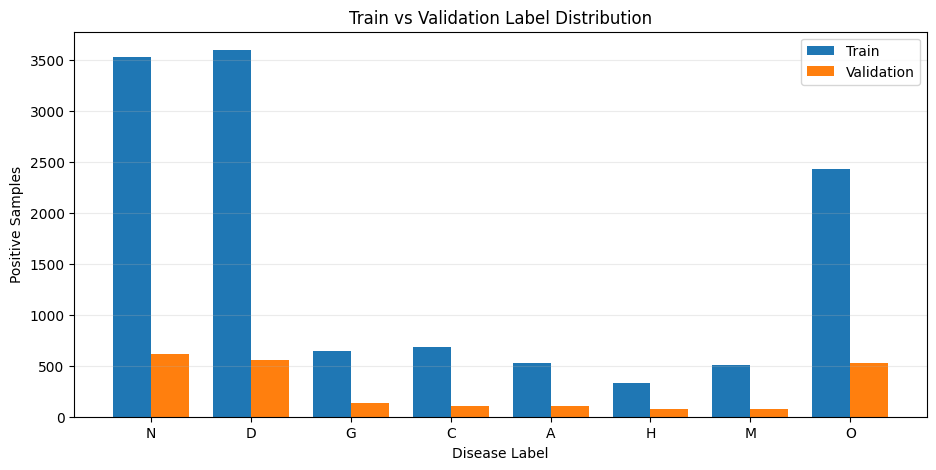

In [19]:
import matplotlib.pyplot as plt

train_label_counts = np.stack([s["label"] for s in train_samples]).sum(axis=0)
val_label_counts = np.stack([s["label"] for s in val_samples]).sum(axis=0)

x = np.arange(len(LABEL_COLS))
width = 0.38

plt.figure(figsize=(11, 5))
plt.bar(x - width/2, train_label_counts, width=width, label="Train")
plt.bar(x + width/2, val_label_counts, width=width, label="Validation")
plt.xticks(x, LABEL_COLS)
plt.title("Train vs Validation Label Distribution")
plt.xlabel("Disease Label")
plt.ylabel("Positive Samples")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()


In [20]:
from model import build_model
import torch.nn as nn
import torch

MODEL_NAME = "resnet50"
# options: "resnet18", "resnet50", "efficientnet_b0", "custom_cnn"

model = build_model(
    model_name=MODEL_NAME,
    num_labels=len(LABEL_COLS),
    dropout=0.3,
    pretrained=(MODEL_NAME != "custom_cnn")
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)

print("Using model:", MODEL_NAME)
print(model.__class__.__name__)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 184MB/s] 


Using model: resnet50
ResNet


In [21]:
@torch.no_grad()
def multilabel_accuracy_from_probs(probs, y, threshold=0.3):
    preds = (probs >= threshold).to(y.dtype)
    return (preds == y).float().mean().item()


def train_one_epoch(model, loader, criterion, optimizer, device="cpu"):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True).float()

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        probs = torch.sigmoid(logits)
        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += multilabel_accuracy_from_probs(probs, y) * bs
        n += bs

    return {
        "loss": total_loss / n,
        "acc": total_acc / n,
    }


@torch.no_grad()
def evaluate_epoch(model, loader, criterion, device="cpu", threshold=0.5):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n = 0
    all_probs = []
    all_targets = []

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True).float()

        logits = model(x)
        loss = criterion(logits, y)
        probs = torch.sigmoid(logits)

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += multilabel_accuracy_from_probs(probs, y, threshold=threshold) * bs
        n += bs

        all_probs.append(probs.cpu())
        all_targets.append(y.cpu())

    probs = torch.cat(all_probs).numpy()
    targets = torch.cat(all_targets).numpy().astype(int)
    preds = (probs >= threshold).astype(int)

    macro_f1 = f1_score(targets, preds, average="macro", zero_division=0)
    micro_f1 = f1_score(targets, preds, average="micro", zero_division=0)
    exact_match = (preds == targets).all(axis=1).mean()
    per_class_f1 = f1_score(targets, preds, average=None, zero_division=0)

    return {
        "loss": total_loss / n,
        "acc": total_acc / n,
        "macro_f1": macro_f1,
        "micro_f1": micro_f1,
        "exact_match": exact_match,
        "per_class_f1": per_class_f1,
        "probs": probs,
        "preds": preds,
        "targets": targets,
    }
best_val_loss = float("inf")
best_epoch_loss = -1
best_state_loss = None

best_val_macro_f1 = -1.0
best_epoch_f1 = -1
best_state_f1 = None
best_metrics_f1 = None

history = []

EARLY_STOPPING_PATIENCE = 10
epochs_no_improve = 0

for epoch in range(1, EPOCHS + 1):
    train_metrics = train_one_epoch(
        model, train_loader, criterion,
        optimizer=optimizer, device=DEVICE
    )

    val_metrics = evaluate_epoch(
        model, val_loader, criterion,
        device=DEVICE, threshold=0.5
    )

    scheduler.step(val_metrics["macro_f1"])
    current_lr = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["acc"],
        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["acc"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_micro_f1": val_metrics["micro_f1"],
        "val_exact_match": val_metrics["exact_match"],
        "lr": current_lr,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_metrics['loss']:.4f} acc {train_metrics['acc']:.4f} | "
        f"val loss {val_metrics['loss']:.4f} acc {val_metrics['acc']:.4f} "
        f"macro_f1 {val_metrics['macro_f1']:.4f} exact {val_metrics['exact_match']:.4f} | "
        f"lr {current_lr:.6f}"
    )

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_epoch_loss = epoch
        best_state_loss = copy.deepcopy(model.state_dict())

    improved_f1 = (
        val_metrics["macro_f1"] > best_val_macro_f1
    ) or (
        np.isclose(val_metrics["macro_f1"], best_val_macro_f1) and
        val_metrics["loss"] < (best_metrics_f1["loss"] if best_metrics_f1 is not None else float("inf"))
    )

    if improved_f1:
        best_val_macro_f1 = val_metrics["macro_f1"]
        best_epoch_f1 = epoch
        best_state_f1 = copy.deepcopy(model.state_dict())
        best_metrics_f1 = {
            "loss": val_metrics["loss"],
            "acc": val_metrics["acc"],
            "macro_f1": val_metrics["macro_f1"],
            "micro_f1": val_metrics["micro_f1"],
            "exact_match": val_metrics["exact_match"],
            "per_class_f1": val_metrics["per_class_f1"],
        }
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"No macro F1 improvement for {epochs_no_improve} epoch(s)")

    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(
            f"Early stopping triggered at epoch {epoch}. "
            f"Best macro F1: {best_val_macro_f1:.4f} at epoch {best_epoch_f1}."
        )
        break

Epoch 01 | train loss 0.8571 acc 0.5090 | val loss 1.0060 acc 0.7887 macro_f1 0.4488 exact 0.1718 | lr 0.000300
Epoch 02 | train loss 0.6868 acc 0.6648 | val loss 1.0069 acc 0.7846 macro_f1 0.4612 exact 0.1329 | lr 0.000300
Epoch 03 | train loss 0.5704 acc 0.7311 | val loss 1.1110 acc 0.8159 macro_f1 0.4929 exact 0.2150 | lr 0.000300
Epoch 04 | train loss 0.4960 acc 0.7689 | val loss 1.1230 acc 0.8198 macro_f1 0.4914 exact 0.2345 | lr 0.000300
No macro F1 improvement for 1 epoch(s)
Epoch 05 | train loss 0.4142 acc 0.8089 | val loss 1.4996 acc 0.8370 macro_f1 0.5038 exact 0.2966 | lr 0.000300
Epoch 06 | train loss 0.3625 acc 0.8375 | val loss 1.4090 acc 0.8458 macro_f1 0.5389 exact 0.3155 | lr 0.000300
Epoch 07 | train loss 0.2939 acc 0.8754 | val loss 1.3654 acc 0.8199 macro_f1 0.4895 exact 0.2572 | lr 0.000300
No macro F1 improvement for 1 epoch(s)
Epoch 08 | train loss 0.2548 acc 0.8952 | val loss 1.6202 acc 0.8297 macro_f1 0.5115 exact 0.2955 | lr 0.000300
No macro F1 improvement fo

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_multilabel_confusion_matrices(targets, preds, class_names=None):
    num_classes = targets.shape[1]

    if class_names is None:
        class_names = [f"Class {i}" for i in range(num_classes)]

    cols = 4
    rows = int(np.ceil(num_classes / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = axes.flatten()

    for i in range(num_classes):
        cm = confusion_matrix(targets[:, i], preds[:, i])

        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(ax=axes[i], colorbar=False)

        axes[i].set_title(class_names[i])

    for j in range(num_classes, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [23]:
checkpoint_dir = "/kaggle/working/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

best_model_f1_path = os.path.join(checkpoint_dir, "resnet18_odir_multilabel_best_f1.pt")
best_model_loss_path = os.path.join(checkpoint_dir, "resnet18_odir_multilabel_best_loss.pt")
last_model_path = os.path.join(checkpoint_dir, "resnet18_odir_multilabel_last.pt")
history_path = os.path.join(checkpoint_dir, "training_history.csv")

if best_state_f1 is not None:
    torch.save(best_state_f1, best_model_f1_path)
if best_state_loss is not None:
    torch.save(best_state_loss, best_model_loss_path)
torch.save(model.state_dict(), last_model_path)
pd.DataFrame(history).to_csv(history_path, index=False)

print(f"Best epoch by macro F1: {best_epoch_f1}")
if best_metrics_f1 is not None:
    print(f"Best val macro F1: {best_metrics_f1['macro_f1']:.4f}")
    print(f"Val loss at best F1 epoch: {best_metrics_f1['loss']:.4f}")
    print(f"Val acc at best F1 epoch: {best_metrics_f1['acc']:.4f}")
    print(f"Val exact match at best F1 epoch: {best_metrics_f1['exact_match']:.4f}")
print(f"Best epoch by val loss: {best_epoch_loss}")
print(f"Best val loss: {best_val_loss:.4f}")
print("Saved best F1 model to:", best_model_f1_path)
print("Saved best loss model to:", best_model_loss_path)
print("Saved last model to:", last_model_path)
print("Saved history to:", history_path)


Best epoch by macro F1: 15
Best val macro F1: 0.5622
Val loss at best F1 epoch: 2.2110
Val acc at best F1 epoch: 0.8599
Val exact match at best F1 epoch: 0.3679
Best epoch by val loss: 1
Best val loss: 1.0060
Saved best F1 model to: /kaggle/working/checkpoints/resnet18_odir_multilabel_best_f1.pt
Saved best loss model to: /kaggle/working/checkpoints/resnet18_odir_multilabel_best_loss.pt
Saved last model to: /kaggle/working/checkpoints/resnet18_odir_multilabel_last.pt
Saved history to: /kaggle/working/checkpoints/training_history.csv


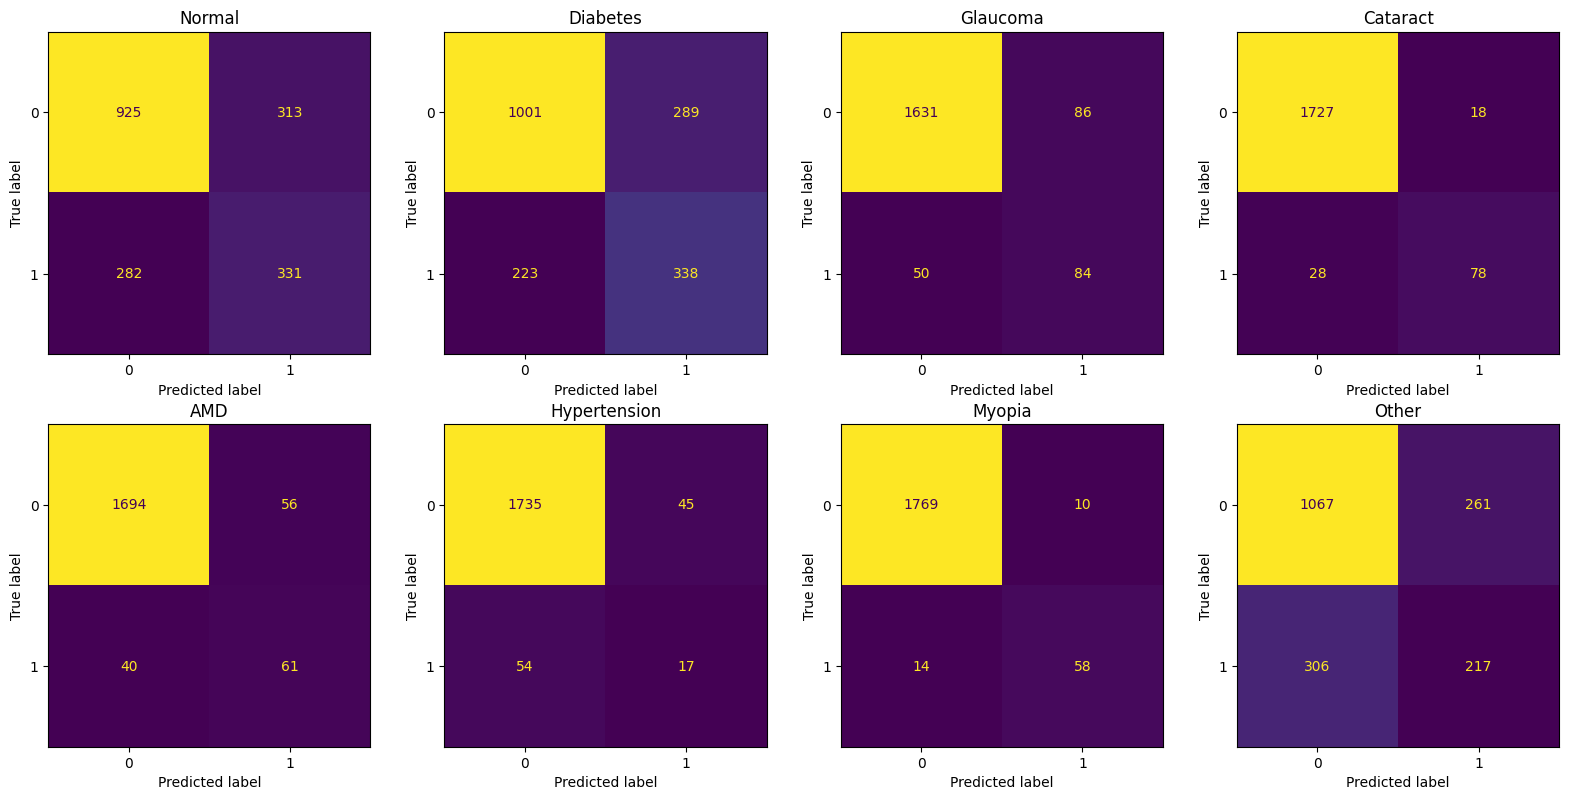

In [24]:
model.load_state_dict(best_state_f1)

val_metrics = evaluate_epoch(
    model, val_loader, criterion,
    device=DEVICE, threshold=0.5
)

plot_multilabel_confusion_matrices(
    val_metrics["targets"],
    val_metrics["preds"],
    class_names=["Normal", "Diabetes", "Glaucoma", "Cataract", "AMD", "Hypertension", "Myopia", "Other"]  # adjust
)

Glaucoma example index: 30


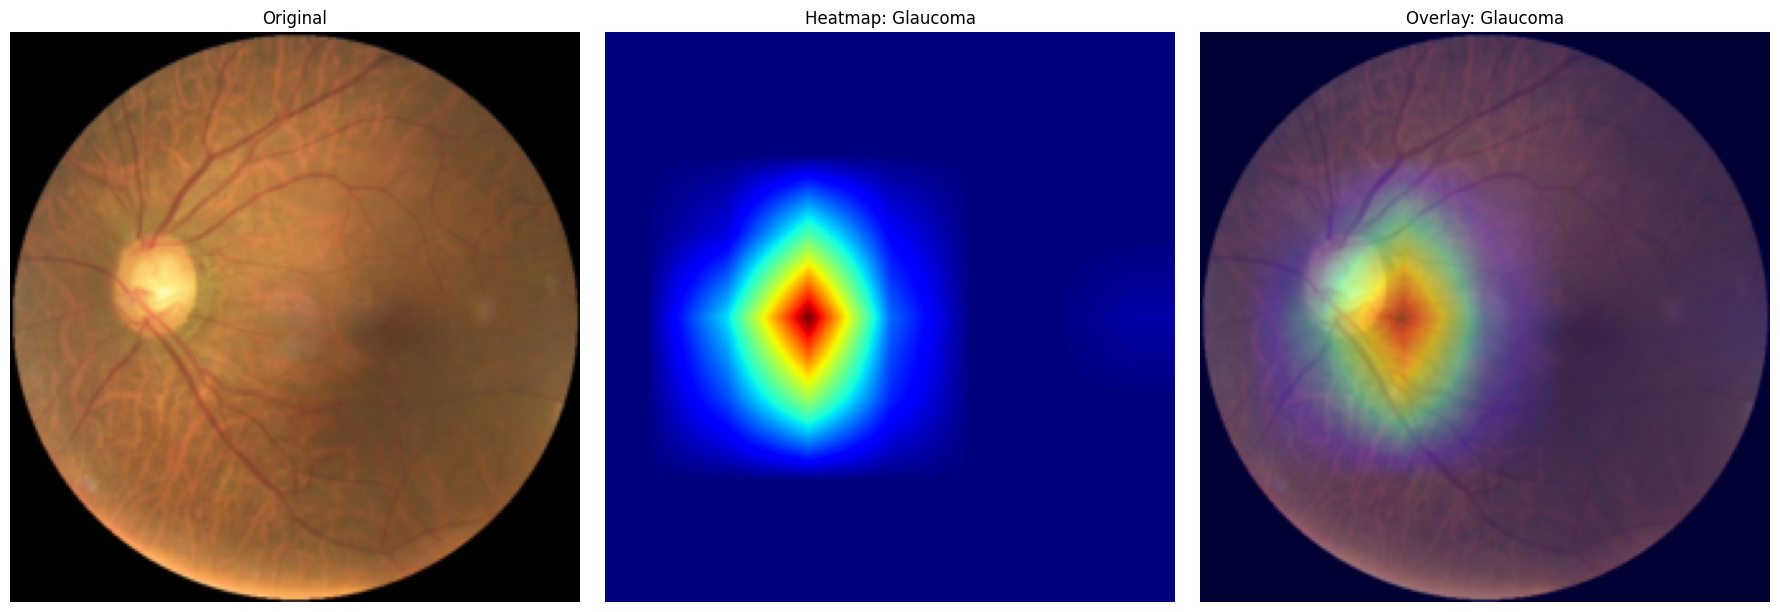

Image: /kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k/preprocessed_images/95_left.jpg
True: ['Glaucoma', 'Hypertension']
Pred: ['Normal', 'Glaucoma']

Probabilities:
        Normal: 0.9187
      Diabetes: 0.0056
      Glaucoma: 0.7030
      Cataract: 0.0004
           AMD: 0.0001
  Hypertension: 0.0005
        Myopia: 0.0001
         Other: 0.0016
AMD example index: 14


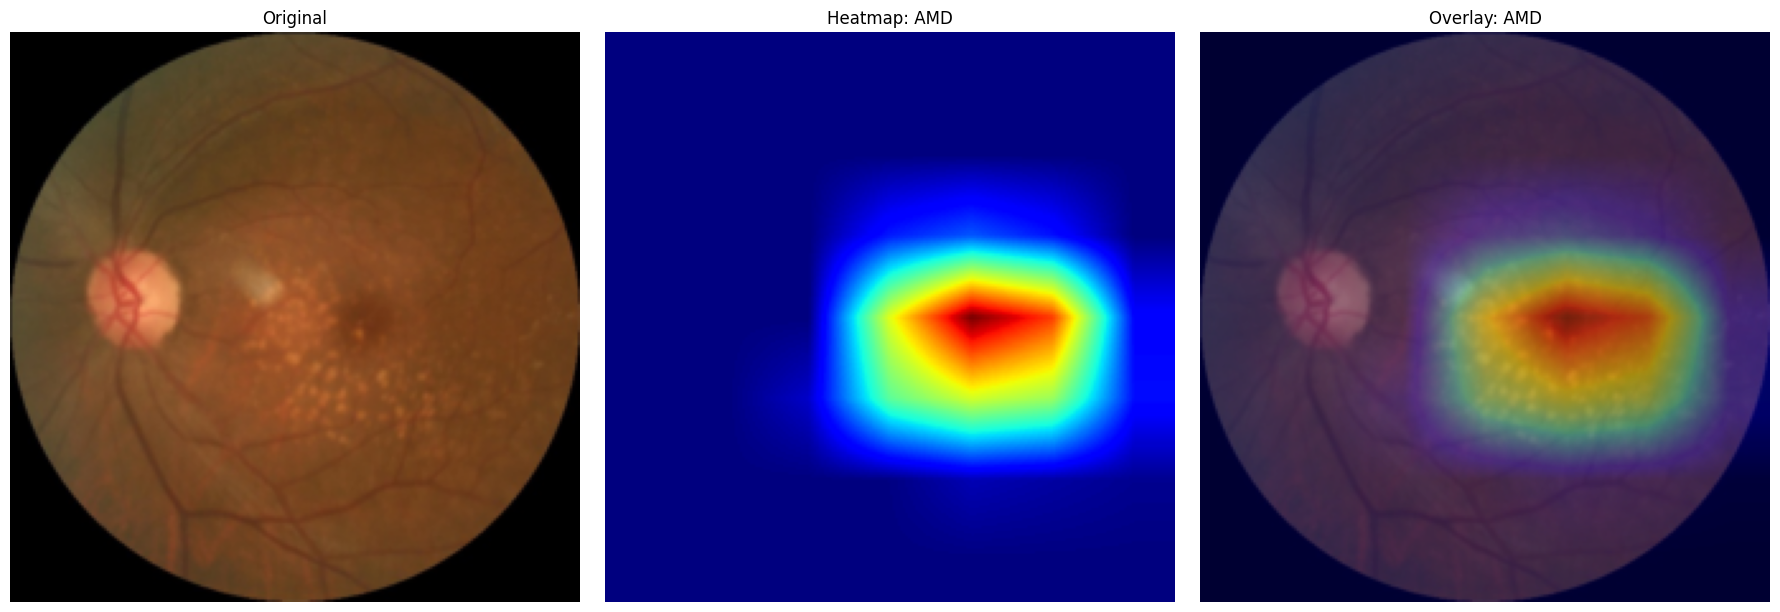

Image: /kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k/preprocessed_images/48_left.jpg
True: ['AMD']
Pred: ['AMD']

Probabilities:
        Normal: 0.0212
      Diabetes: 0.0002
      Glaucoma: 0.0005
      Cataract: 0.0000
           AMD: 0.9997
  Hypertension: 0.0001
        Myopia: 0.0001
         Other: 0.0003


In [25]:
# =========================
# GRAD-CAM (ALL-IN-ONE CELL)
# =========================

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# -------- CLASS NAMES --------
CLASS_NAMES = ["Normal", "Diabetes", "Glaucoma", "Cataract", "AMD", "Hypertension", "Myopia", "Other"]

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

def unnormalize_image(tensor):
    img = tensor.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * IMAGENET_STD + IMAGENET_MEAN
    return np.clip(img, 0, 1)

# -------- GRAD-CAM CLASS --------
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, inp, out):
        self.activations = out

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, x, class_idx):
        self.model.eval()
        self.model.zero_grad()

        logits = self.model(x)
        score = logits[0, class_idx]
        score.backward(retain_graph=True)

        grads = self.gradients
        acts = self.activations

        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam[0, 0].detach().cpu().numpy()

        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        else:
            cam = np.zeros_like(cam)

        probs = torch.sigmoid(logits).detach().cpu().numpy()[0]
        return cam, probs

# -------- INITIALISE --------
grad_cam = GradCAM(model, model.layer4[-1])

# -------- FIND GOOD EXAMPLE --------
def find_example_for_class(target_class_idx, threshold=0.5):
    for i in range(len(val_samples)):
        sample = val_samples[i]
        if sample["label"][target_class_idx] != 1:
            continue

        pil_img = Image.open(sample["path"]).convert("RGB")
        x = val_tfm(pil_img).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            probs = torch.sigmoid(model(x))[0].cpu().numpy()

        if probs[target_class_idx] >= threshold:
            return i
    return None

# -------- MAIN FUNCTION --------
def run_gradcam(sample_idx=None, class_idx=None, threshold=0.5):
    if sample_idx is None:
        sample_idx = 0

    sample = val_samples[sample_idx]
    img_path = sample["path"]
    true_label = sample["label"]

    pil_img = Image.open(img_path).convert("RGB")
    x = val_tfm(pil_img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        probs = torch.sigmoid(model(x))[0].cpu().numpy()

    if class_idx is None:
        class_idx = int(np.argmax(probs))

    cam, probs = grad_cam.generate(x, class_idx)
    img_np = unnormalize_image(x[0])

    true_positive = [CLASS_NAMES[i] for i, v in enumerate(true_label) if v == 1]
    pred_positive = [CLASS_NAMES[i] for i, p in enumerate(probs) if p >= threshold]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(img_np)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(cam, cmap="jet")
    axes[1].set_title(f"Heatmap: {CLASS_NAMES[class_idx]}")
    axes[1].axis("off")

    axes[2].imshow(img_np)
    axes[2].imshow(cam, cmap="jet", alpha=0.4)
    axes[2].set_title(f"Overlay: {CLASS_NAMES[class_idx]}")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Image: {img_path}")
    print(f"True: {true_positive if true_positive else ['None']}")
    print(f"Pred: {pred_positive if pred_positive else ['None']}")
    print("\nProbabilities:")
    for i, p in enumerate(probs):
        print(f"{CLASS_NAMES[i]:>14}: {p:.4f}")

# =========================
# RUN EXAMPLES
# =========================


# Auto best example for Glaucoma (2)
idx = find_example_for_class(target_class_idx=2)
print("Glaucoma example index:", idx)
run_gradcam(sample_idx=idx, class_idx=2)

# Auto best example for AMD (4)
idx = find_example_for_class(target_class_idx=4)
print("AMD example index:", idx)
run_gradcam(sample_idx=idx, class_idx=4)

# Or random image:
#run_gradcam(sample_idx=10)

# =========================
# SHOW MULTIPLE EXAMPLES (10)
# =========================

# NUM_EXAMPLES = 10
# threshold = 0.5

# for i in range(NUM_EXAMPLES):
#     class_idx = i % len(CLASS_NAMES)  # cycle through classes

#     idx = find_example_for_class(target_class_idx=class_idx, threshold=threshold)

#     print("\n" + "="*50)
#     print(f"Example {i+1}/{NUM_EXAMPLES}")
#     print(f"Class: {CLASS_NAMES[class_idx]}")
#     print(f"Index found: {idx}")

#     if idx is not None:
#         run_gradcam(sample_idx=idx, class_idx=class_idx, threshold=threshold)
#     else:
#         print(f"No suitable example found for class: {CLASS_NAMES[class_idx]}")

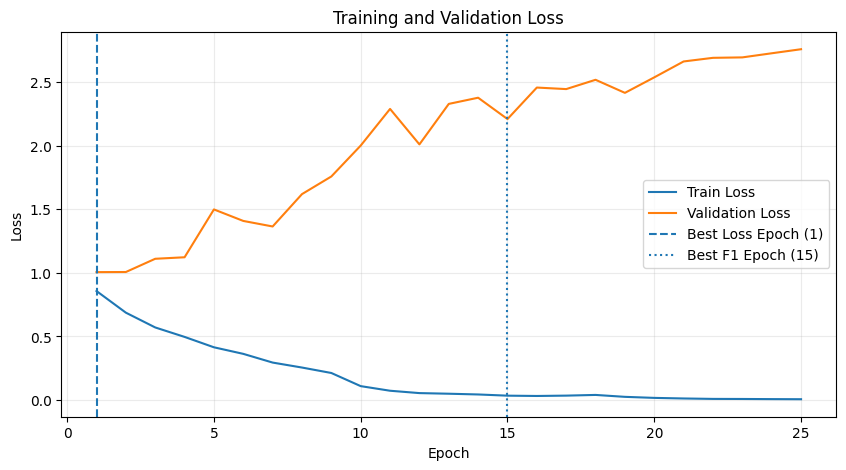

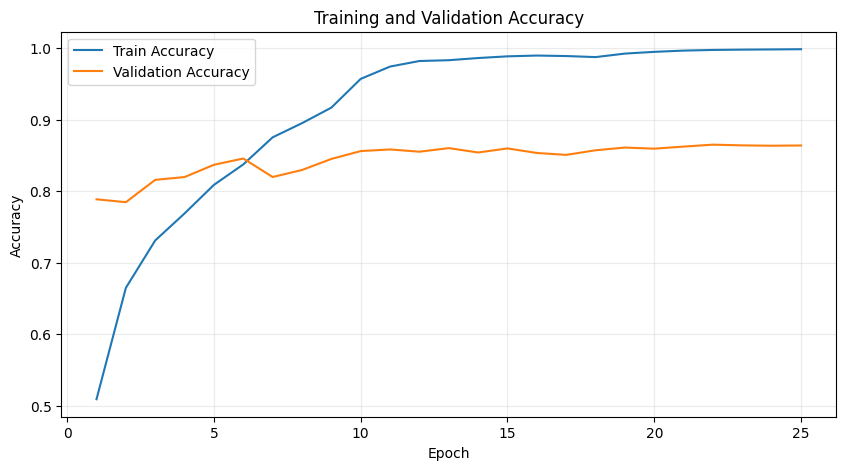

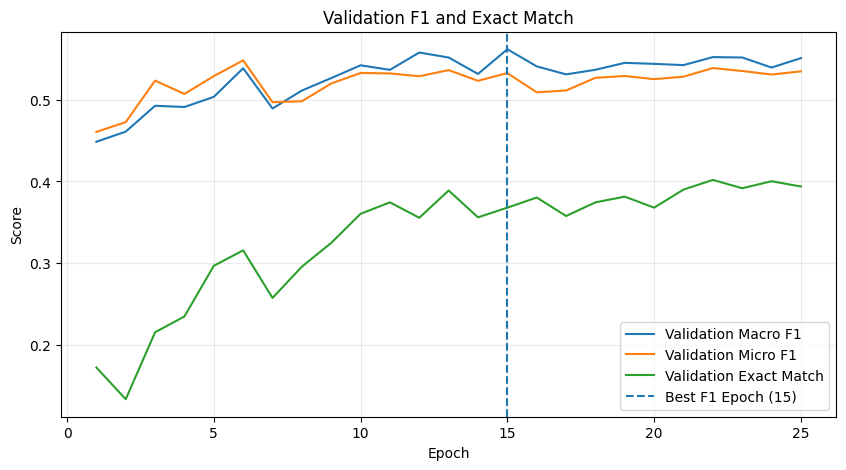

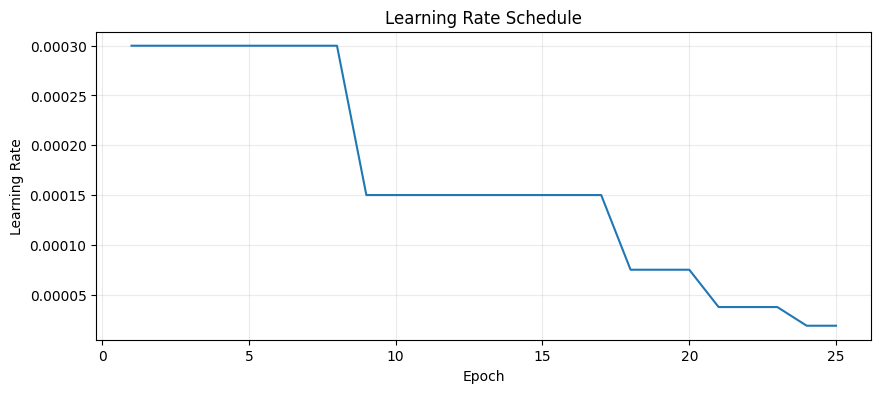

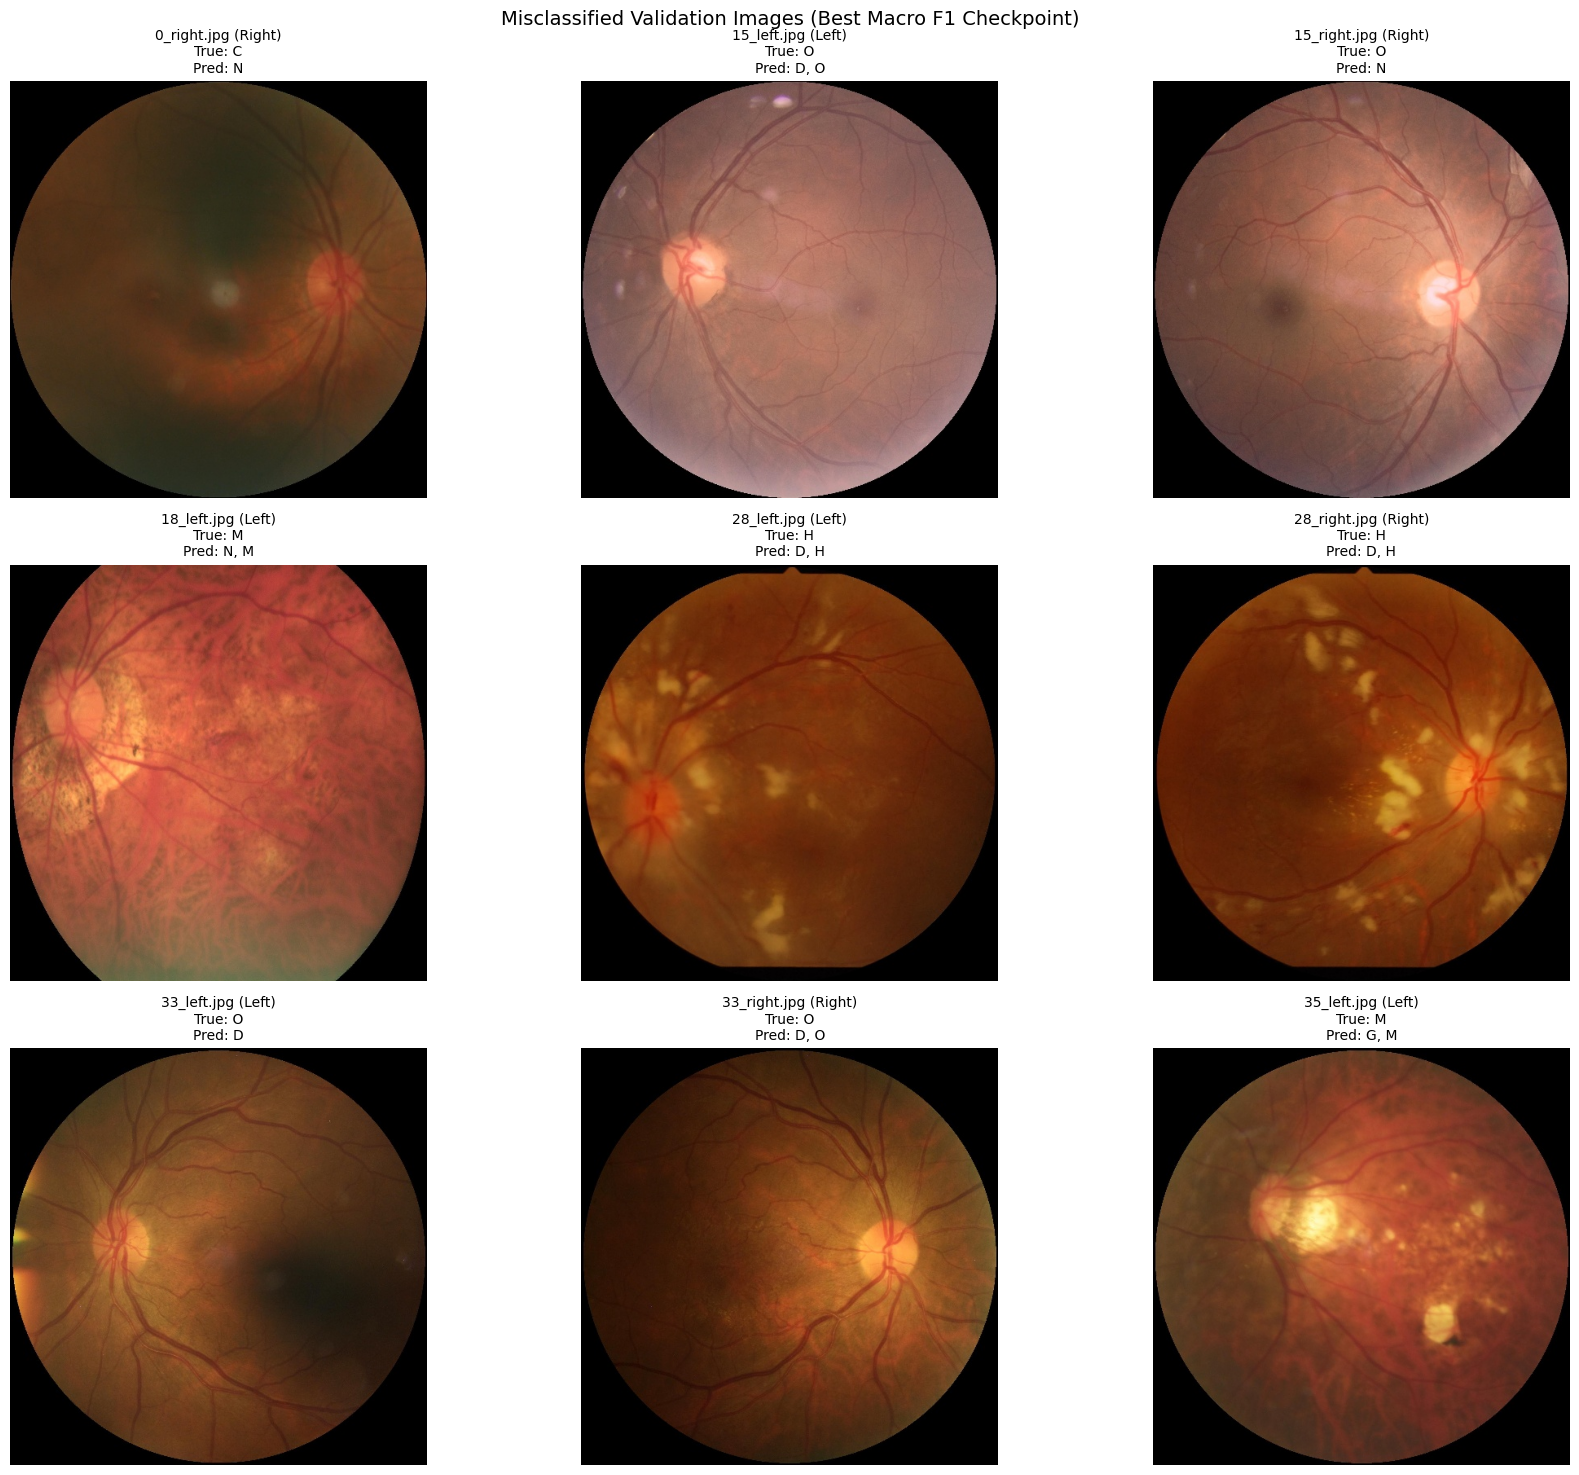

In [27]:
# =========================
# VISUALISATIONS: TRAINING CURVES AND MISCLASSIFIED IMAGES
# =========================
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history)

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.axvline(best_epoch_loss, linestyle="--", label=f"Best Loss Epoch ({best_epoch_loss})")
plt.axvline(best_epoch_f1, linestyle=":", label=f"Best F1 Epoch ({best_epoch_f1})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="Validation Macro F1")
plt.plot(history_df["epoch"], history_df["val_micro_f1"], label="Validation Micro F1")
plt.plot(history_df["epoch"], history_df["val_exact_match"], label="Validation Exact Match")
plt.axvline(best_epoch_f1, linestyle="--", label=f"Best F1 Epoch ({best_epoch_f1})")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation F1 and Exact Match")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_df["epoch"], history_df["lr"])
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")
plt.grid(alpha=0.25)
plt.show()

# Load best-F1 model before error analysis
if best_state_f1 is not None:
    model.load_state_dict(best_state_f1)

@torch.no_grad()
def collect_misclassified_samples(model, samples, tfm, device="cpu", threshold=0.5, max_items=None):
    model.eval()
    mistakes = []

    for sample in samples:
        img = Image.open(sample["path"]).convert("RGB")
        x = tfm(img).unsqueeze(0).to(device)
        logits = model(x)
        probs = torch.sigmoid(logits).squeeze(0).cpu().numpy()
        preds = (probs >= threshold).astype(int)
        true = sample["label"].astype(int)

        if not np.array_equal(preds, true):
            mistakes.append({
                "path": sample["path"],
                "filename": sample["filename"],
                "side": sample["side"],
                "true": true,
                "pred": preds,
                "probs": probs,
            })

            if max_items is not None and len(mistakes) >= max_items:
                break

    return mistakes

def decode_labels(vec):
    labels = [LABEL_COLS[i] for i, v in enumerate(vec) if v == 1]
    return labels if labels else ["None"]

def show_misclassified_images(mistakes, ncols=3):
    if len(mistakes) == 0:
        print("No misclassified validation images found with the current threshold.")
        return

    n = len(mistakes)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, item in zip(axes, mistakes):
        img = Image.open(item["path"]).convert("RGB")
        ax.imshow(img)
        true_labels = ", ".join(decode_labels(item["true"]))
        pred_labels = ", ".join(decode_labels(item["pred"]))
        ax.set_title(
            f"{item['filename']} ({item['side']})\nTrue: {true_labels}\nPred: {pred_labels}",
            fontsize=10
        )
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.suptitle("Misclassified Validation Images (Best Macro F1 Checkpoint)", fontsize=14)
    plt.tight_layout()
    plt.show()

# Count all mistakes
misclassified_all = collect_misclassified_samples(
    model, val_samples, val_tfm, device=DEVICE, threshold=0.5, max_items=None
)

total_misclassified = len(misclassified_all)
total_val = len(val_samples)
misclassified_pct = 100 * total_misclassified / total_val

# Show a subset
show_misclassified_images(misclassified_all[:9], ncols=3)
